In [25]:
import pandas as pd      # For data manipulation (tables, CSV, Excel)
import numpy as np       # For numerical computations
import matplotlib.pyplot as plt   # Basic plotting
import seaborn as sns             # Advanced statistical visuals

In [23]:
df = pd.read_csv(r'C:\Users\USER\OneDrive\Documents\amazon.csv')

In [24]:
df.info() #information about data 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [26]:
df['discounted_price'] = df['discounted_price'].str.replace('₹','').str.replace(',','').astype(float) #clean price columns
df['actual_price'] = df['actual_price'].str.replace('₹','').str.replace(',','').astype(float)

In [27]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].str.replace(',','')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')#clean rating and rating count

In [28]:
df['discount_amount'] = df['actual_price'] - df['discounted_price']
df['discount_percent_calc'] = (df['discount_amount'] / df['actual_price']) * 100

In [31]:
df.isnull().sum()

product_id               0
product_name             0
category                 0
discounted_price         0
actual_price             0
discount_percentage      0
rating                   0
rating_count             0
about_product            0
user_id                  0
user_name                0
review_id                0
review_title             0
review_content           0
img_link                 0
product_link             0
discount_amount          0
discount_percent_calc    0
dtype: int64

In [30]:
df = df.dropna(subset=['rating', 'rating_count'])

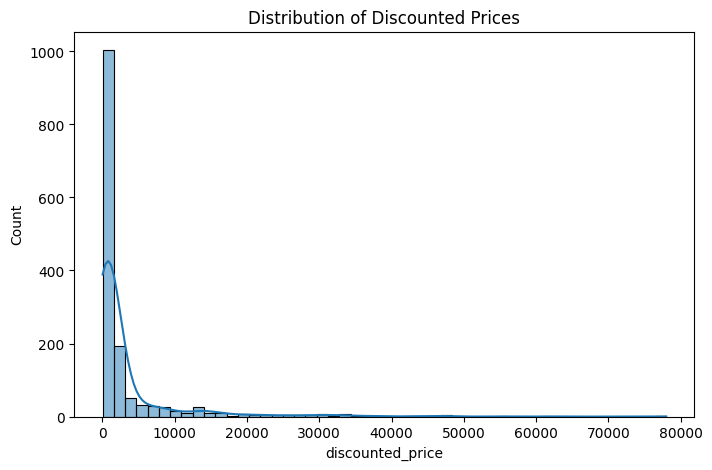

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['discounted_price'], bins=50, kde=True)
plt.title("Distribution of Discounted Prices")
plt.show()

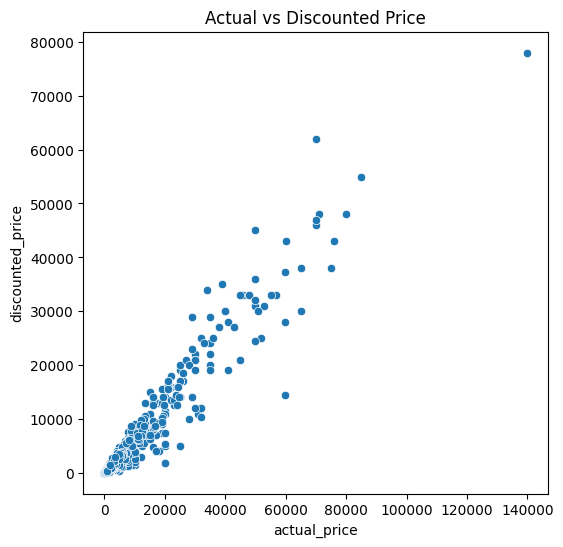

In [33]:
plt.figure(figsize=(6,6))
sns.scatterplot(x='actual_price', y='discounted_price', data=df)
plt.title("Actual vs Discounted Price")
plt.show()

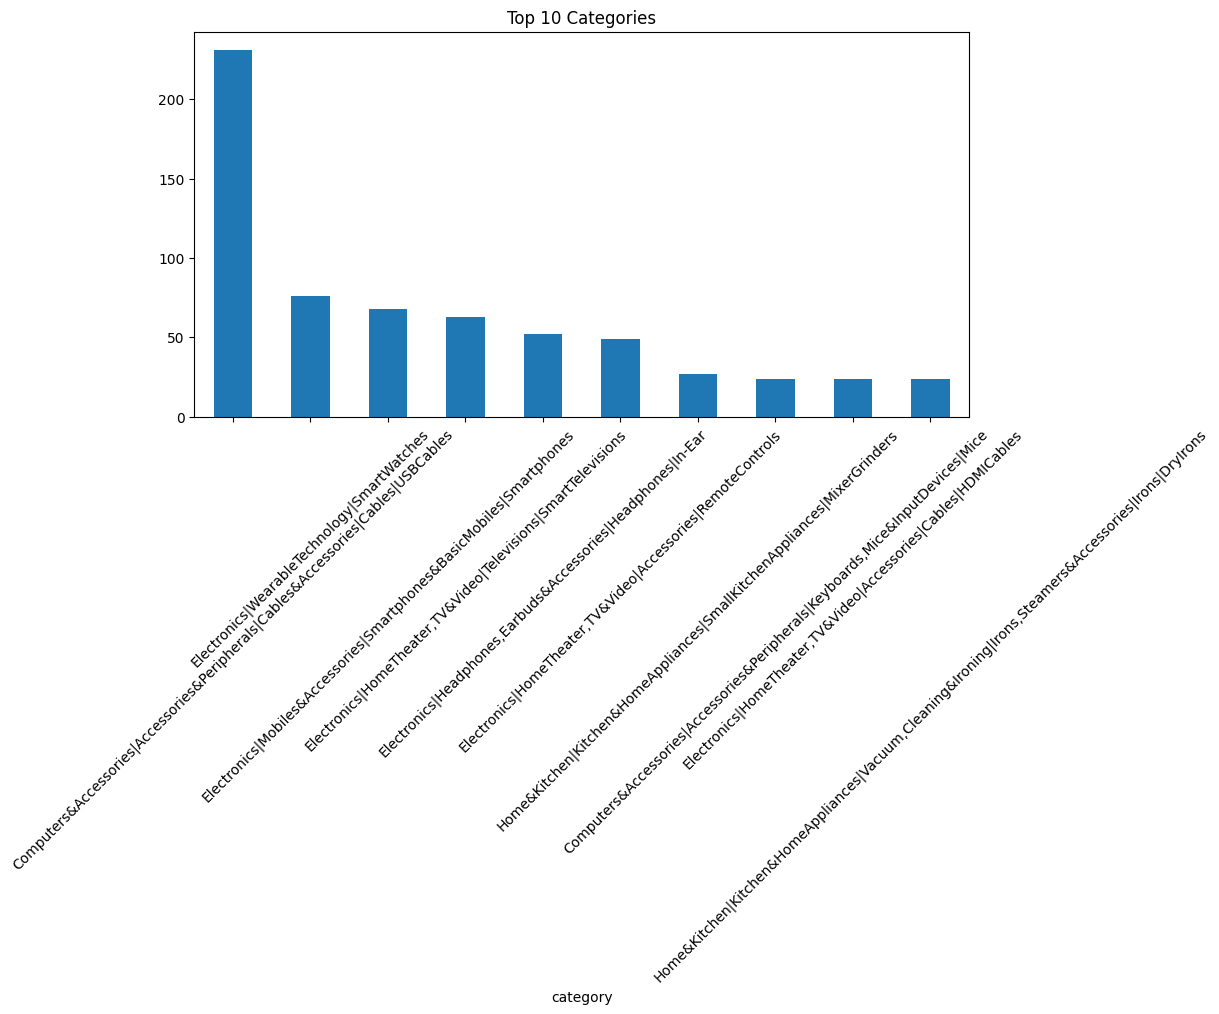

In [34]:
plt.figure(figsize=(10,5))
df['category'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Categories")
plt.xticks(rotation=45)
plt.show()

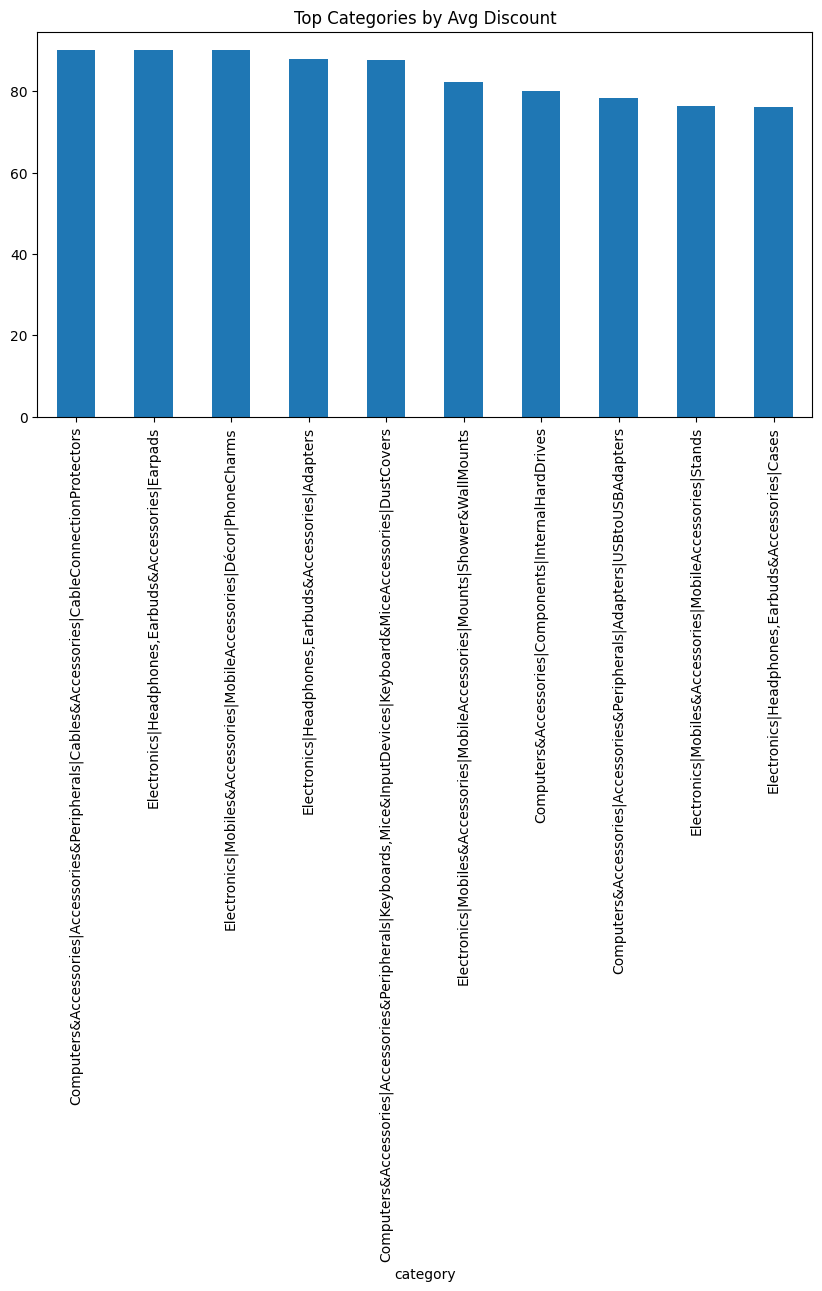

In [35]:
category_discount = df.groupby('category')['discount_percent_calc'].mean().sort_values(ascending=False).head(10)

category_discount.plot(kind='bar', figsize=(10,5))
plt.title("Top Categories by Avg Discount")
plt.show()

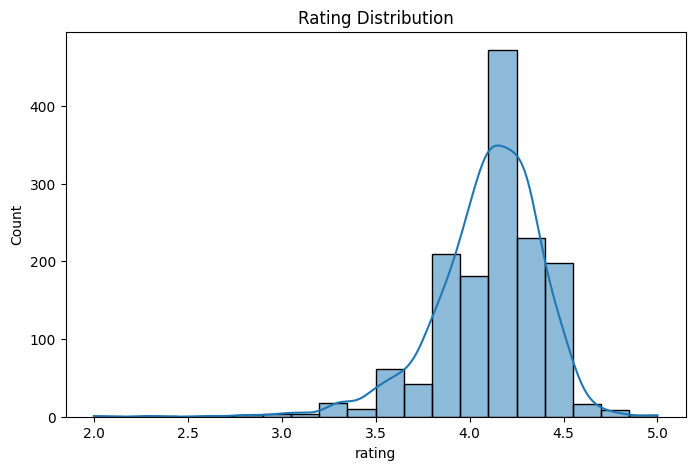

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

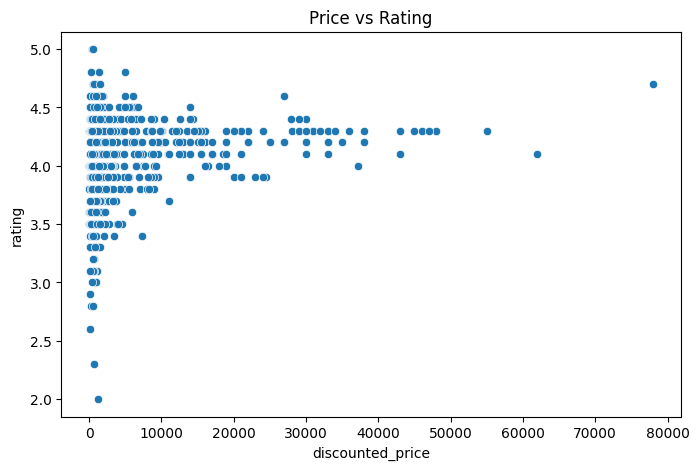

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='discounted_price', y='rating', data=df)
plt.title("Price vs Rating")
plt.show()

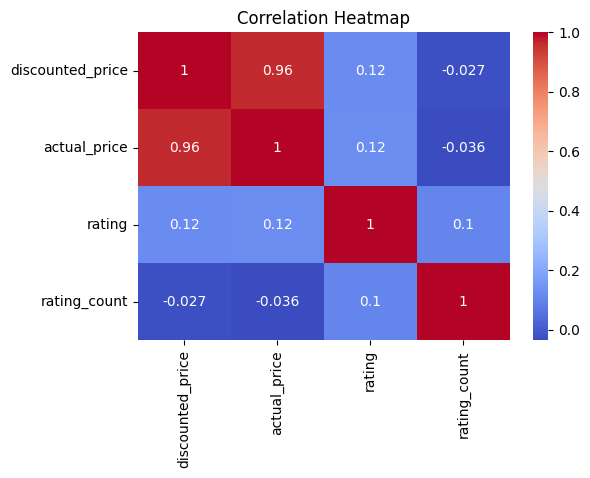

In [38]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['discounted_price','actual_price','rating','rating_count']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [39]:
df.sort_values(by='rating_count', ascending=False)[['product_name','rating_count']].head(10) #TOP 10 reviewed product 

,product_name,rating_count
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973.0
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973.0
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973.0
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,426972.0
400,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0
352,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,363711.0
370,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836.0
371,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836.0
566,"Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...",313832.0


In [40]:
df.sort_values(by='discount_percent_calc', ascending=False)[['product_name','discount_percent_calc']].head(10) # Most valued product 

,product_name,discount_percent_calc
695,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",94.118824
372,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.004550
380,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.004550
334,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.004550
368,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.004550
364,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.004550
602,LAPSTER Spiral Charger Spiral Charger Cable Pr...,90.090090
557,LAPSTER 12pcs Spiral Cable Protectors for Char...,90.090090
920,"Silicone Rubber Earbuds Tips, Eartips, Earpads...",90.090090
644,Sounce Spiral Charger Cable Protector Data Cab...,90.090090


In [41]:
# KEY INSIGHTS
# Most products are priced in the low to mid range, with few high-price outliers.
# Discounts are common, but they show little impact on product ratings.
# Product ratings are generally high (around 4+), indicating a positive bias.
# Few products dominate reviews, while most have very low rating counts.
# Price and rating are weakly related — expensive products aren’t necessarily better rated.
# Data is category-skewed, with a few categories dominating the dataset.

In [ ]:
# CONCLUSION 
# “The dataset shows that affordability drives product distribution, while popularity is concentrated among a few items, 
# and discounts have limited influence on customer ratings.”